Per-dataset namespace via `DatasetCtx`. Each dataset (iEEG, reconstructed sources) populates its own ctx object so globals never collide.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from pesco.experimental.clustering import (
    cluster_bands,
    cluster_peak_frequencies,
    find_k_with_no_peak,
    get_no_peak,
    order_clusters_by_peak,
)
from pesco.experimental.peak_testing import (
    compute_intervals,
    cutintervals,
    test_lobes,
    test_regions,
    test_regions_heatmap,
)
from pesco.experimental.plotting import (
    plot_cluster_brain,
    plot_clusters,
    plot_histogram,
    plot_lobes,
    plot_region_difference_heatmap,
    plot_regions,
)
from pesco.io import load_sources, prepare_psd
from pesco.pipeline import DatasetCtx
from pesco.preprocess import compute_psd, normalize_psd

seed = 3
np.random.seed(seed)

PROJECT_DIR = Path("/Users/daniel/PhD/spectral-comparison/code/")
DATA_PATH_SOURCES = Path(f"{PROJECT_DIR}/data/Mantini2018")
DATA_PATH_IEEG = Path(f"{PROJECT_DIR}/data/Frauscher2018")

NO_PEAK_SUMMARY = "mean"
PLOT_SUMMARY = "median"

## iEEG

In [2]:
ieeg = DatasetCtx(name="intracranial data")
ieeg.f, ieeg.psd = prepare_psd(
    DATA_PATH_IEEG / "WakefulnessMatlabFile.mat",
    DATA_PATH_IEEG / "RegionInformation.csv",
)
assert ieeg.psd is not None

ieeg.psd

,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,...,79.0,79.5,80.0,ChannelRegion,patient,mni_x,mni_y,mni_z,Region name,Lobe
channel,,,,,,,,,,,,,,,,,,,,,
GD001Lc_11,0.092947,0.114337,0.093374,0.067704,0.042922,0.040393,0.036007,0.034783,0.045677,0.039419,...,0.000052,0.000038,0.000037,31,1,-56.000000,-37.000000,-2.000000,'Middle temporal gyrus',Temporal
GD001Lc_12,0.090270,0.147761,0.127372,0.075875,0.046717,0.039750,0.041112,0.037464,0.043440,0.036571,...,0.000090,0.000054,0.000046,31,1,-60.000000,-37.000000,-4.000000,'Middle temporal gyrus',Temporal
GD001Lc_13,0.079443,0.125797,0.091377,0.059805,0.054049,0.050969,0.035467,0.041534,0.044547,0.037190,...,0.000093,0.000053,0.000043,31,1,-63.000000,-37.000000,-2.000000,'Middle temporal gyrus',Temporal
GD001Lc_14,0.166364,0.194635,0.096108,0.048454,0.039237,0.026046,0.020449,0.024757,0.030056,0.022768,...,0.000028,0.000018,0.000010,31,1,-68.000000,-38.000000,-2.000000,'Middle temporal gyrus',Temporal
GD001Lo_1,0.140135,0.179327,0.118761,0.096757,0.064853,0.043011,0.050224,0.051905,0.043115,0.053518,...,0.000159,0.000152,0.000118,19,1,-1.000000,42.000000,-14.000000,'Medial frontal cortex',Frontal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NG110RG614,0.034908,0.102428,0.130893,0.076009,0.046062,0.041571,0.041874,0.038723,0.048300,0.065662,...,0.000025,0.000015,0.000013,6,110,64.958333,-6.500000,13.666667,'Postcentral gyrus (including medial segment)',Parietal
NG110RG64,0.039227,0.089204,0.113189,0.090483,0.061624,0.053920,0.063370,0.060249,0.050575,0.080074,...,0.000016,0.000015,0.000012,21,110,48.464286,27.464286,-1.285714,'Frontal operculum',Frontal
NG110RG65,0.067036,0.150605,0.133164,0.077352,0.071302,0.058644,0.048273,0.045799,0.040558,0.038862,...,0.000025,0.000017,0.000019,21,110,52.535714,15.035714,-0.214286,'Frontal operculum',Frontal


In [5]:
k, ieeg.psd_clust, ieeg.smal = find_k_with_no_peak(
    ieeg.psd,
    k_range=range(2, 16),
    feature_cols=ieeg.f,
    summary=NO_PEAK_SUMMARY,
    random_seed=seed,
)

print(f"selected k={k}, no-peak cluster(s): {ieeg.smal}")

no_peak_df, no_peak_center = get_no_peak(
    ieeg.psd_clust, ieeg.smal, feature_cols=ieeg.f, summary=NO_PEAK_SUMMARY,
)

assert no_peak_df is not None and no_peak_center is not None
ieeg.no_peak_df = no_peak_df
ieeg.no_peak_center = no_peak_center


selected k=8, no-peak cluster(s): [3]


In [6]:
ieeg.peaks = cluster_peak_frequencies(
    ieeg.psd_clust,
    ieeg.f,
    summary=PLOT_SUMMARY,
    baseline=ieeg.no_peak_center,
    freq_range=(1.0, 80.0),
    feature_cols=ieeg.f,
    no_peak=ieeg.smal,
)
print(ieeg.peaks)

{0: 14.0, 1: 2.0, 2: 7.0, 3: None, 4: 5.5, 5: 1.0, 6: 9.0, 7: 20.5}


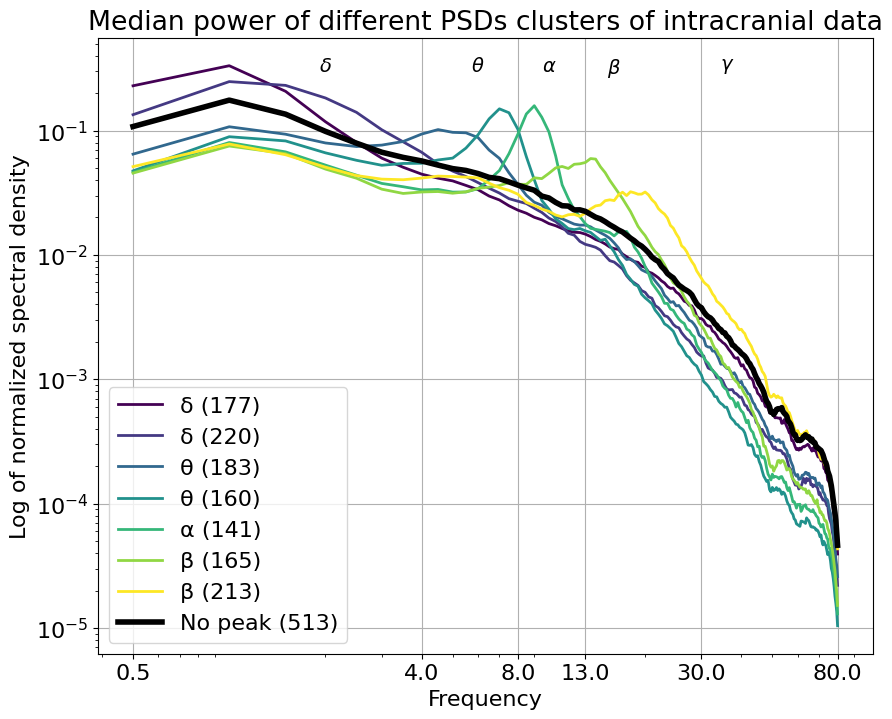

In [7]:
fig, _ = plot_clusters(
    ieeg.psd_clust,
    ieeg.f,
    ieeg.name,
    ieeg.smal,
    nopeak=ieeg.smal[0] if ieeg.smal else None,
    summary=PLOT_SUMMARY,
    log_y=True,
    order_by_peak=True,
    peak_baseline=ieeg.no_peak_center,
    peak_freq_range=(1.0, 80.0),
    feature_cols=ieeg.f,
    label_by_band=True,
)
fig.savefig("ieeg_clusters.png", dpi=600, bbox_inches="tight")

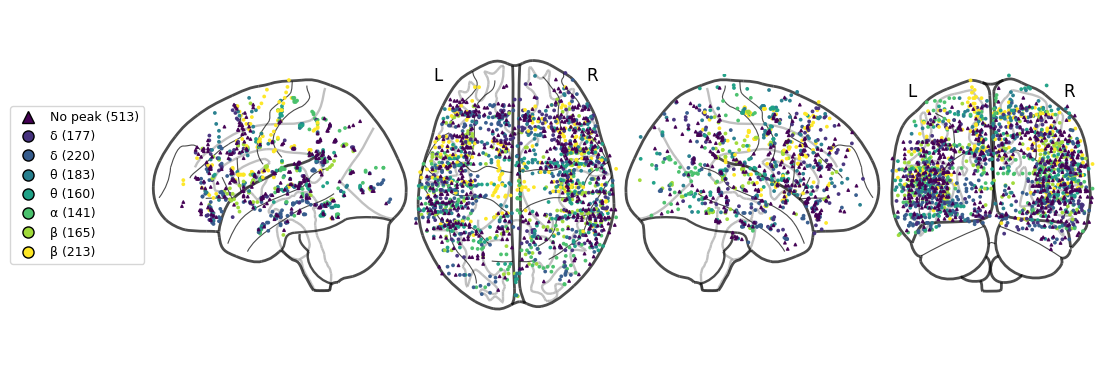

In [8]:
pos = ieeg.psd_clust[["mni_x", "mni_y", "mni_z"]].to_numpy()
labels = ieeg.psd_clust["clusters"].to_numpy()

order = list(ieeg.smal) + order_clusters_by_peak(
    ieeg.psd_clust,
    ieeg.f,
    summary=PLOT_SUMMARY,
    exclude=ieeg.smal,
    baseline=ieeg.no_peak_center,
    freq_range=(1.0, 80.0),
    feature_cols=ieeg.f,
)
band_names = cluster_bands(ieeg.peaks)

plot_cluster_brain(
    pos,
    labels,
    label_names=band_names,
    label_order=order,
    label_markers={k: "^" for k in (ieeg.smal or [])},
    node_size=3,
    alpha=0.95,
    legend_bbox=(-0.15, 0.5),
    output_path="images/ieeg_cluster_brain.svg",
)

In [9]:
ieeg.colbin, _ = cutintervals(ieeg.f)
ieeg.regional_diff = test_regions_heatmap(
    no_peak_df=ieeg.no_peak_df,
    psd=ieeg.psd,
    colbin=ieeg.colbin,
)
ieeg.sig_lobes = test_lobes(ieeg.no_peak_df, ieeg.psd, ieeg.colbin)
ieeg.sig_regions = test_regions(ieeg.no_peak_df, ieeg.psd, ieeg.colbin)

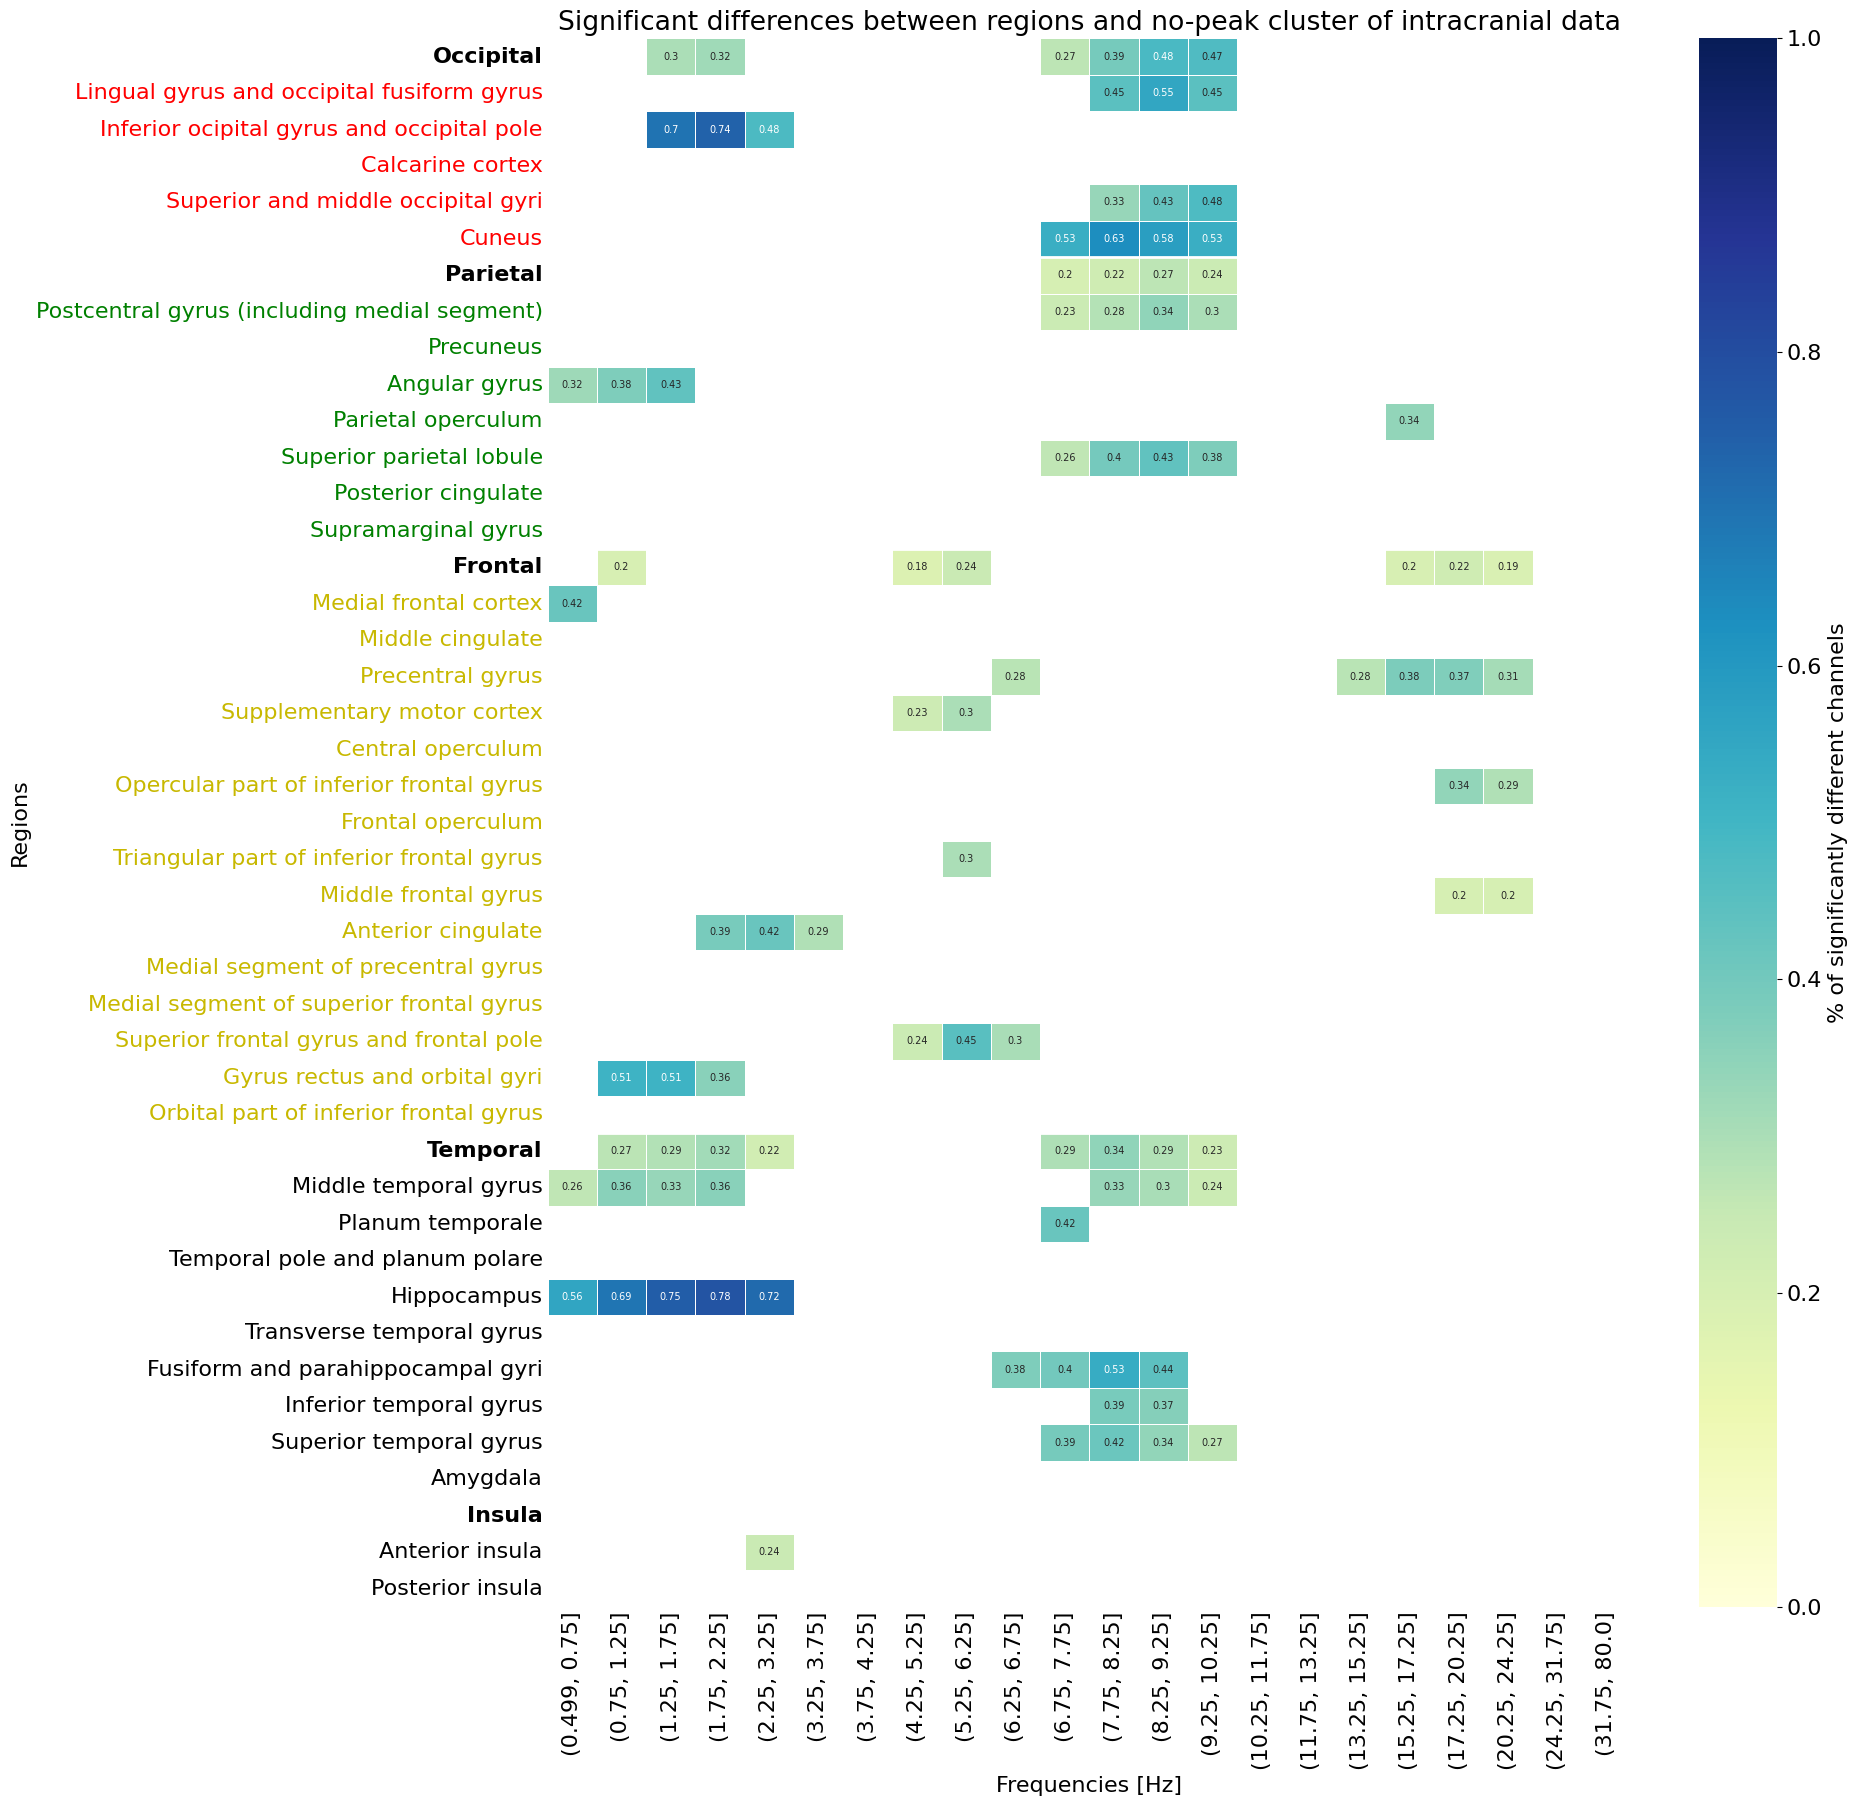

In [10]:
fig, ax = plot_region_difference_heatmap(
    ieeg.regional_diff,
    title=f"Significant differences between regions and no-peak cluster of {ieeg.name}",
    output_path=f"images/{ieeg.name}_all_regional_differences.png",
    annot_fontsize=7,
)

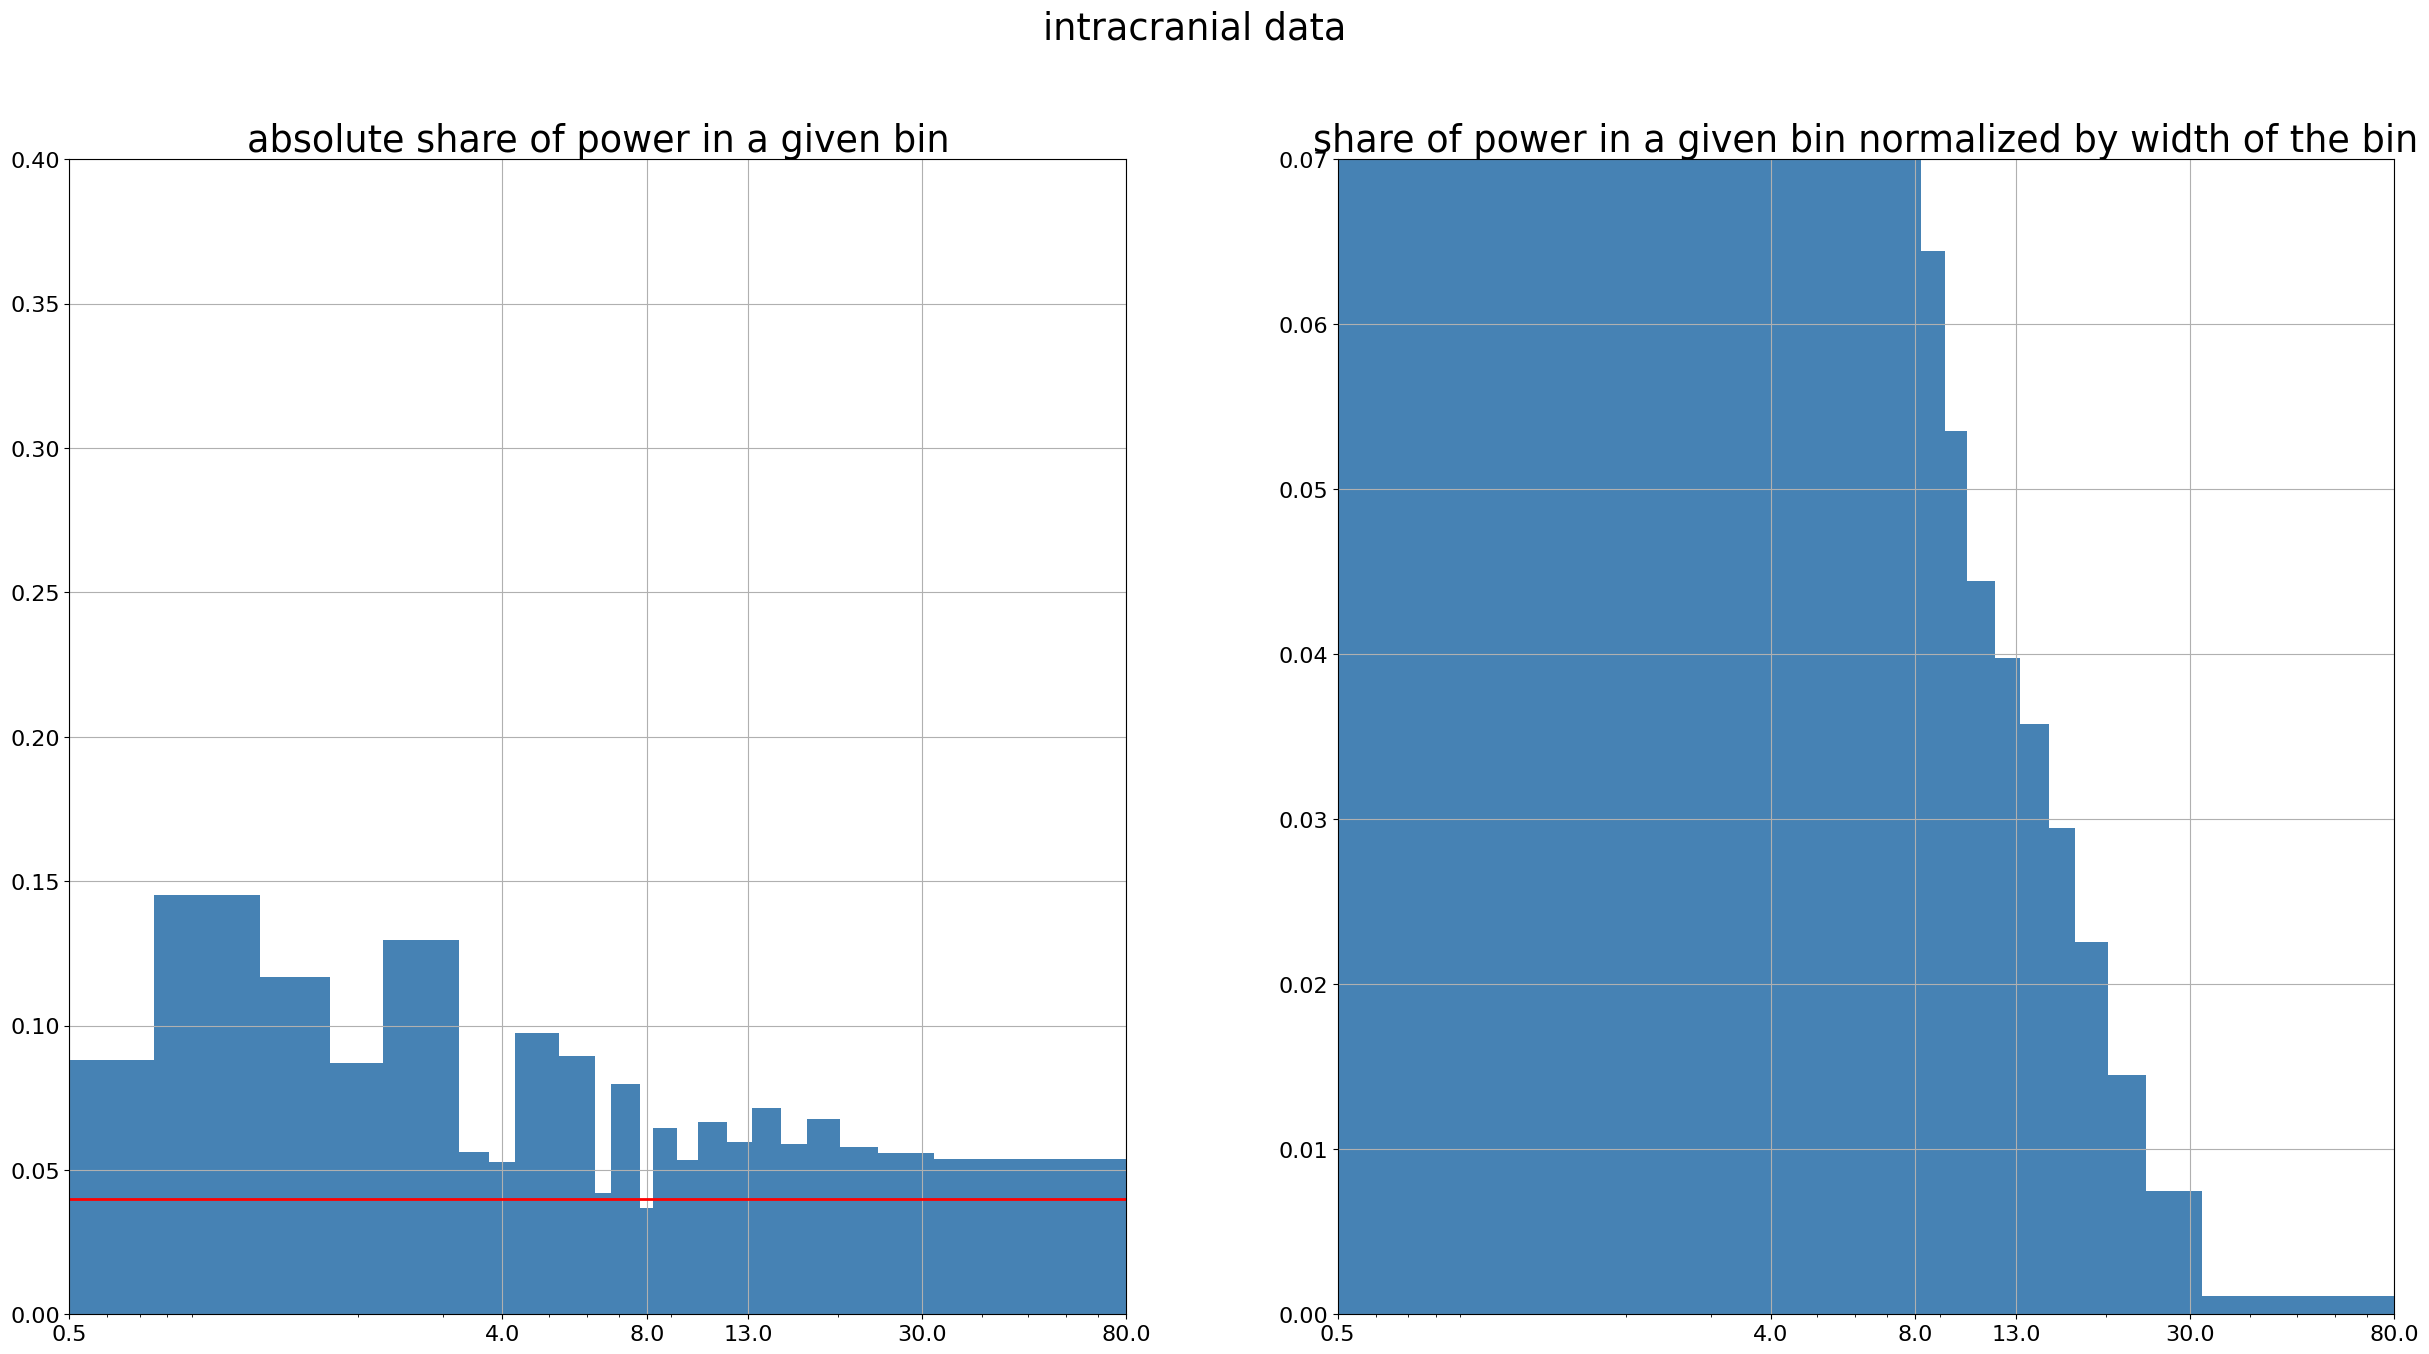

In [11]:
fig, _ = plot_histogram(ieeg.psd, ieeg.colbin, ieeg.name, summary=PLOT_SUMMARY)
fig.savefig(f"images/{ieeg.name}_power_share.png", dpi=600, bbox_inches="tight")

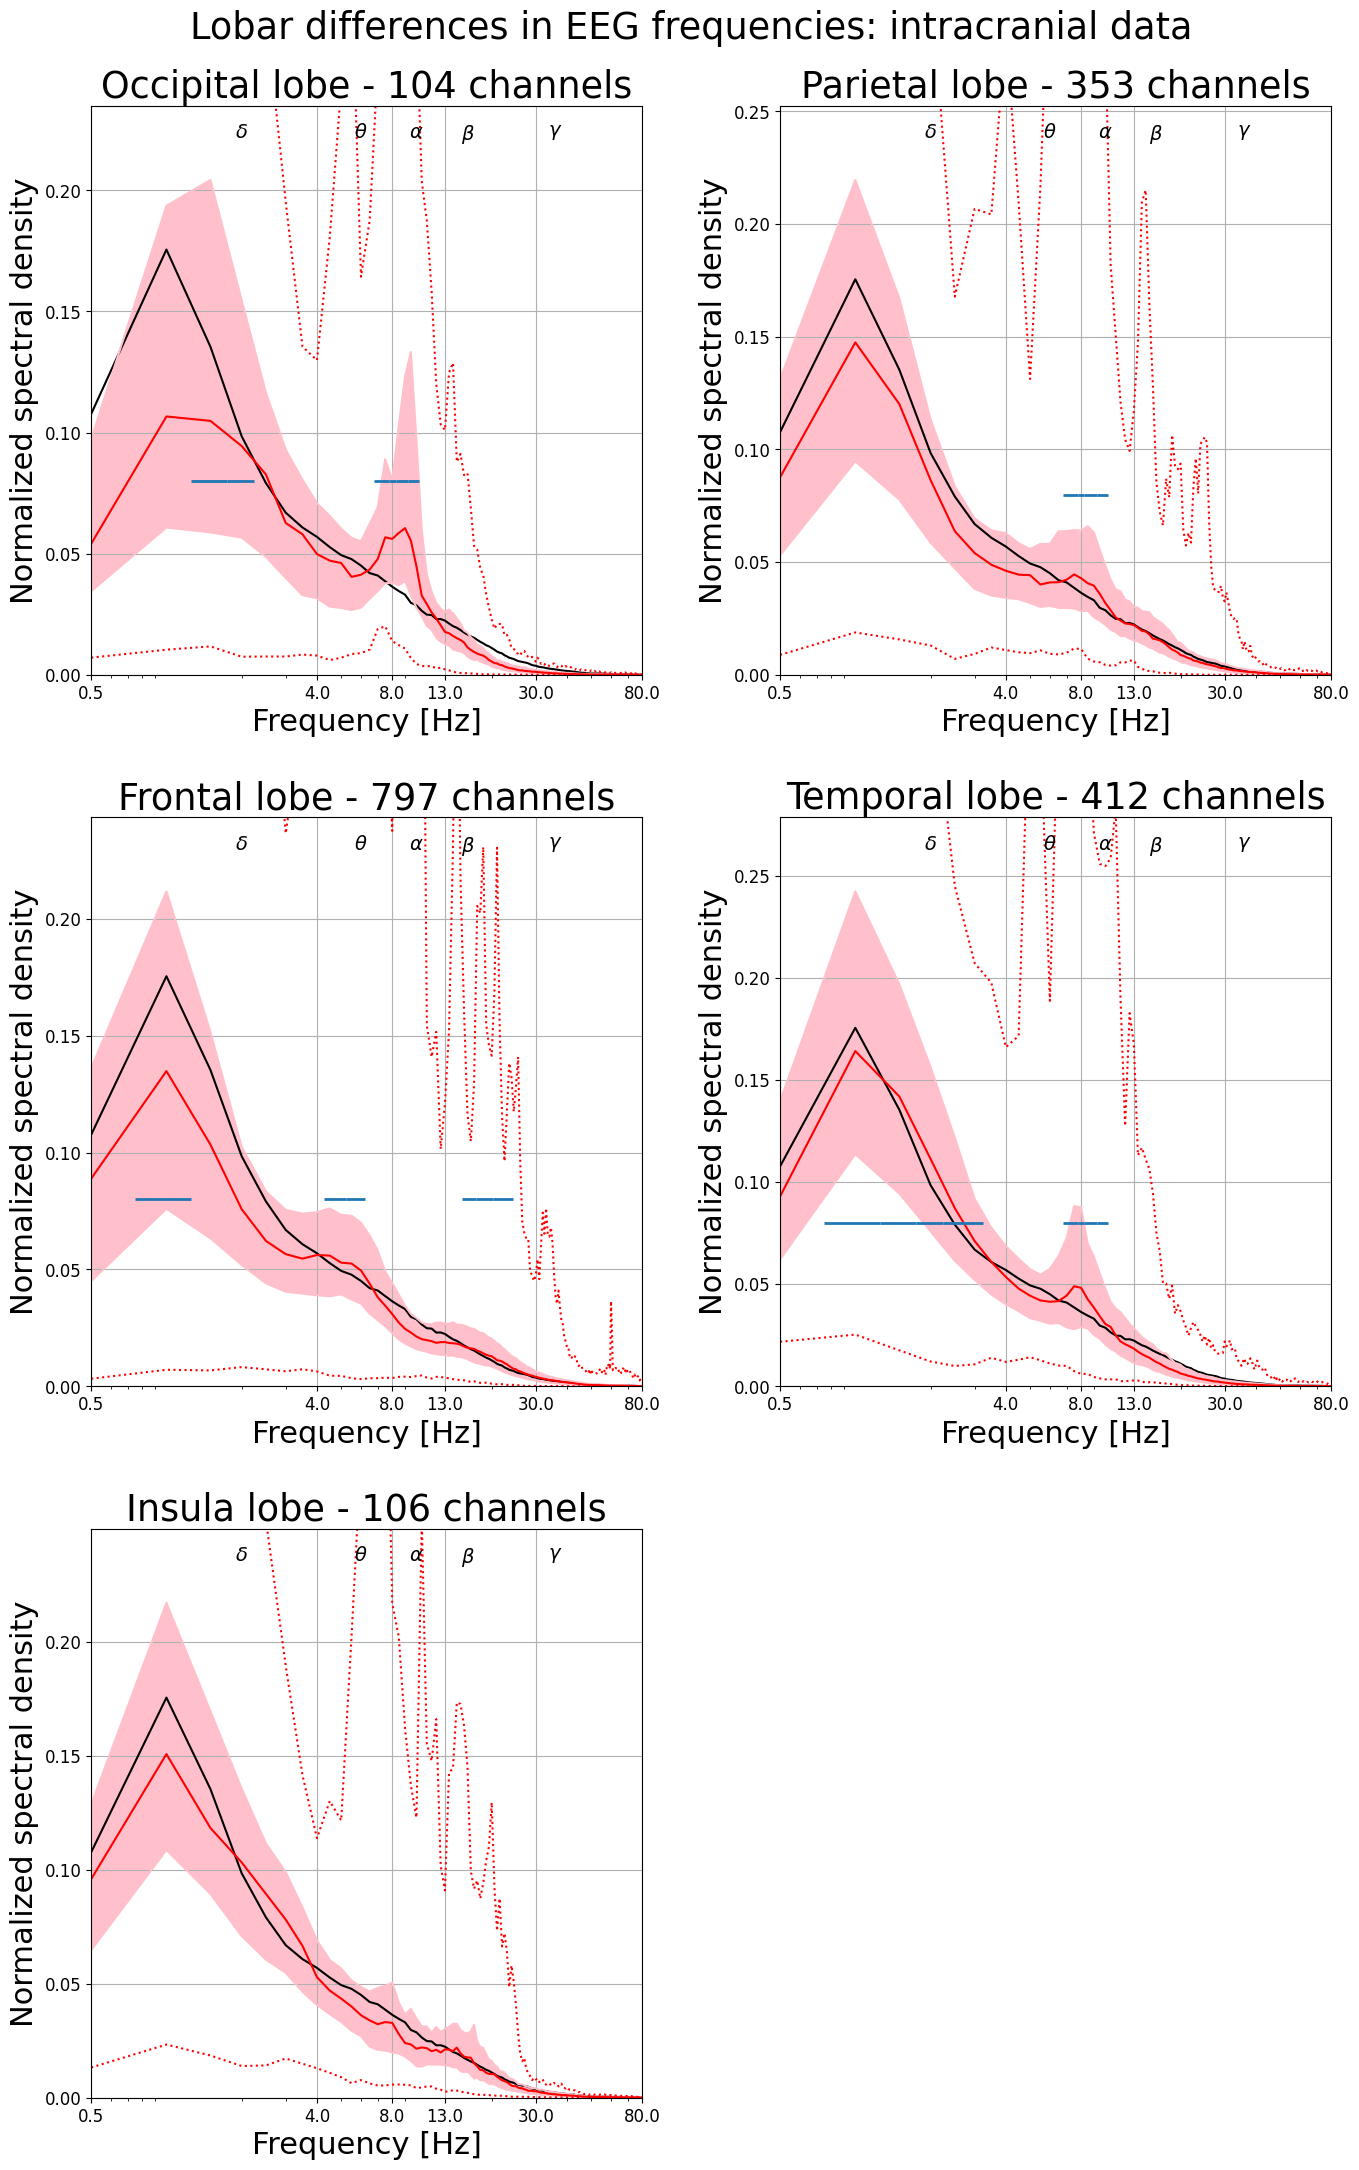

In [12]:
fig, axes = plot_lobes(
    ieeg.psd_clust, ieeg.psd, ieeg.f, ieeg.smal, ieeg.name, ieeg.sig_lobes,
    summary=PLOT_SUMMARY, tick_labelsize=12,
)
fig.savefig(f"images/{ieeg.name}_lobar_differences.pdf", bbox_inches="tight")

## Reconstructed sources

Variation: custom loader, dataset-specific frequency intervals computed from data (paper bins do not satisfy the 4% condition for source PSDs).

In [13]:
SOURCE_DURATION_SECONDS = 60.0
SOURCE_START_SECONDS = None  # None: centered 60 s segment
FREQ_RANGE = (1, 80.0)
USE_FRAUSCHER_BINS = False

src = DatasetCtx(name="reconstructed sources")

raw_src, region_meta = load_sources(DATA_PATH_SOURCES)
n_samples = int(SOURCE_DURATION_SECONDS * raw_src.info["sfreq"])
if n_samples > raw_src.n_times:
    raise ValueError("Source recording shorter than SOURCE_DURATION_SECONDS.")
if SOURCE_START_SECONDS is None:
    src_start = (raw_src.n_times - n_samples) // 2
else:
    src_start = int(SOURCE_START_SECONDS * raw_src.info["sfreq"])
src_stop = src_start + n_samples
print(f"source PSD segment: {src_start / raw_src.info['sfreq']:.1f}-{src_stop / raw_src.info['sfreq']:.1f} s")

data = raw_src.get_data(start=src_start, stop=src_stop)
src.f, psd_arr = compute_psd(
    data, raw_src.info["sfreq"], fmin=FREQ_RANGE[0], fmax=FREQ_RANGE[1],
)
psd_arr = normalize_psd(psd_arr, src.f)
src.psd = pd.DataFrame(
    psd_arr, index=raw_src.info["ch_names"], columns=src.f,
).join(region_meta)
src.psd

Creating RawArray with float64 data, n_channels=1444, n_times=62689
    Range : 0 ... 62688 =      0.000 ...   313.440 secs
Ready.
source PSD segment: 126.7-186.7 s


,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,...,79.5,80.0,region_number,Region name,Lobe,hemisphere,dataset,mni_x,mni_y,mni_z
dataset01_01R,0.076113,0.065432,0.036185,0.024909,0.018321,0.020041,0.023272,0.023090,0.021611,0.030759,...,0.000658,0.000469,1,'Superior and middle occipital gyri',Occipital,R,sources,38.252817,-80.434666,21.695919
dataset01_01L,0.333721,0.224716,0.111641,0.108349,0.079389,0.063929,0.063542,0.053665,0.056184,0.054897,...,0.001578,0.001323,1,'Superior and middle occipital gyri',Occipital,L,sources,-35.071396,-77.866285,25.680365
dataset01_02R,0.064440,0.057557,0.023981,0.018841,0.013341,0.012898,0.015692,0.019536,0.021711,0.027534,...,0.000278,0.000199,2,'Inferior ocipital gyrus and occipital pole',Occipital,R,sources,45.549254,-74.207853,-3.549357
dataset01_02L,0.762324,0.388881,0.115757,0.058308,0.053477,0.047800,0.032406,0.026870,0.026681,0.022165,...,0.001537,0.001377,2,'Inferior ocipital gyrus and occipital pole',Occipital,L,sources,-38.126674,-80.314732,3.256962
dataset01_03R,0.076181,0.063418,0.032549,0.018651,0.017823,0.012747,0.011920,0.014812,0.018130,0.018748,...,0.000690,0.000616,3,'Cuneus',Occipital,R,sources,13.262449,-70.704756,20.277574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dataset09_36L,0.135956,0.084020,0.076278,0.057651,0.054524,0.045691,0.043743,0.028738,0.023412,0.015901,...,0.002288,0.001871,36,'Fusiform and parahippocampal gyri',Temporal,L,sources,-36.604190,-50.425849,-14.207009
dataset09_37R,0.197934,0.129897,0.091853,0.071094,0.078469,0.055851,0.046465,0.032762,0.030874,0.025972,...,0.002620,0.002204,37,'Hippocampus',Temporal,R,sources,30.439324,-25.327861,-13.224525
dataset09_37L,0.150814,0.095526,0.085586,0.066220,0.059376,0.049116,0.048087,0.032013,0.026227,0.019146,...,0.002173,0.001829,37,'Hippocampus',Temporal,L,sources,-29.389070,-22.283960,-13.036641
dataset09_38R,0.183458,0.139465,0.097533,0.072083,0.074020,0.058592,0.049467,0.033245,0.033760,0.030450,...,0.002284,0.002017,38,'Amygdala',Temporal,R,sources,26.596026,-3.838147,-17.376756


In [15]:
_, src.psd_clust, src.smal = find_k_with_no_peak(
    src.psd,
    k_range=range(2, 16),
    feature_cols=src.f,
    summary=NO_PEAK_SUMMARY,
    random_seed=seed,
)
print(f"no-peak cluster(s): {src.smal}")

no_peak_df, no_peak_center = get_no_peak(
    ieeg.psd_clust, ieeg.smal, feature_cols=ieeg.f, summary=NO_PEAK_SUMMARY,
)
assert no_peak_df is not None and no_peak_center is not None
ieeg.no_peak_df = no_peak_df
ieeg.no_peak_center = no_peak_center


no-peak cluster(s): [8]


In [16]:
src.peaks = cluster_peak_frequencies(
    src.psd_clust,
    src.f,
    summary=PLOT_SUMMARY,
    baseline=src.no_peak_center,
    freq_range=(1.0, 80.0),
    feature_cols=src.f,
    no_peak=src.smal,
)
print(src.peaks)

{0: 69.0, 1: 9.0, 2: 11.0, 3: 9.5, 4: 11.0, 5: 11.0, 6: 1.0, 7: 9.5, 8: None, 9: 60.5, 10: 9.5}


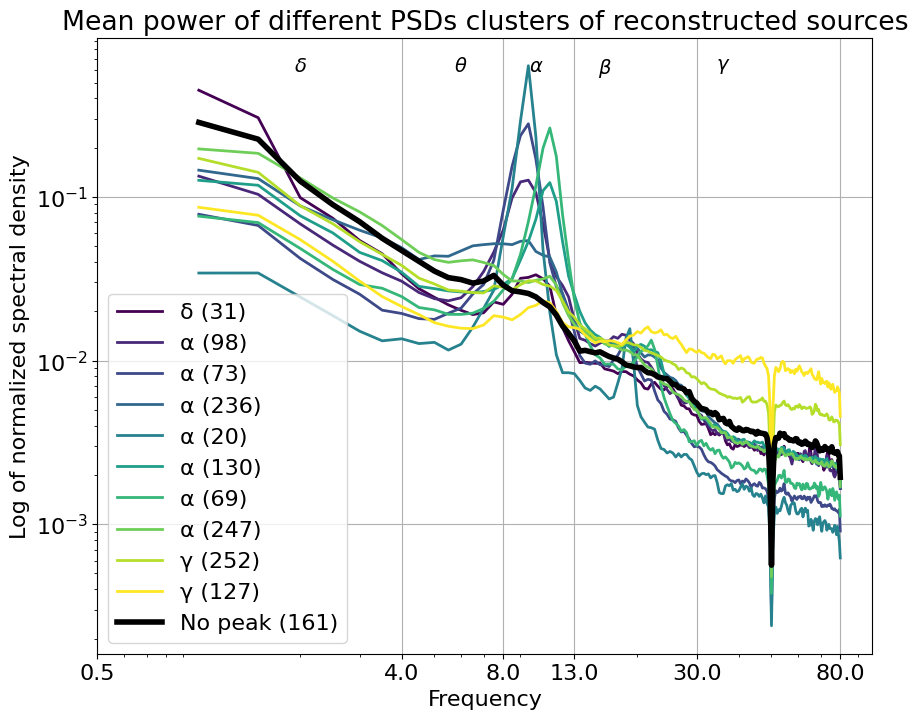

In [17]:
fig, _ = plot_clusters(
    src.psd_clust,
    src.f,
    src.name,
    src.smal,
    nopeak=src.smal[0] if src.smal else None,
    summary="mean",
    log_y=True,
    order_by_peak=True,
    peak_baseline=src.no_peak_center,
    peak_freq_range=(1.0, 80.0),
    feature_cols=src.f,
    label_by_band=True,
)
fig.savefig("reconstructed_sources_clusters.png", dpi=600, bbox_inches="tight")

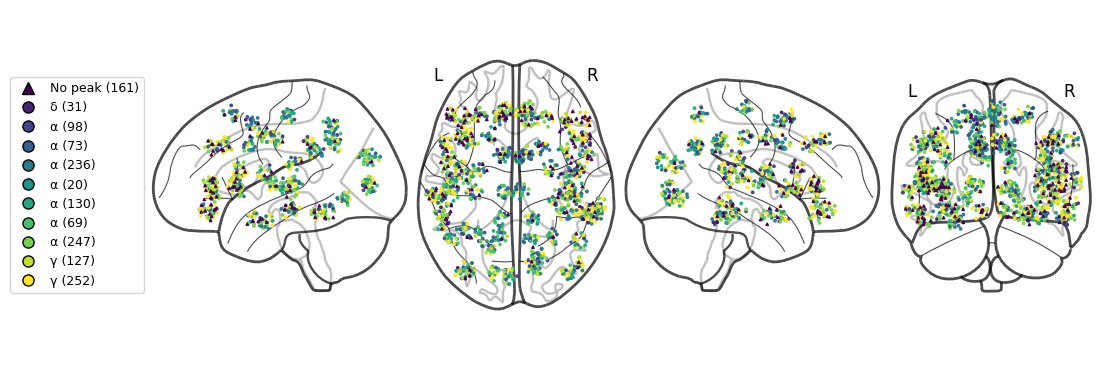

In [18]:
# jittered MNI coords for brain plot (regions overlap otherwise)
psd_clust_jitter = src.psd_clust.copy()
coord_cols = ["mni_x", "mni_y", "mni_z"]
rng = np.random.default_rng(42)
jitter_sd_mm = 4.0
max_jitter_mm = 6.0
jitter = rng.normal(0.0, jitter_sd_mm, size=(len(psd_clust_jitter), 3))
dist = np.linalg.norm(jitter, axis=1)
too_far = dist > max_jitter_mm
jitter[too_far] *= (max_jitter_mm / dist[too_far])[:, None]
psd_clust_jitter[coord_cols] = (
    psd_clust_jitter[coord_cols].to_numpy(dtype=float) + jitter
)

pos = psd_clust_jitter[coord_cols].to_numpy()
labels = psd_clust_jitter["clusters"].to_numpy()

order = list(src.smal) + order_clusters_by_peak(
    src.psd_clust,
    src.f,
    summary=PLOT_SUMMARY,
    exclude=src.smal,
    baseline=src.no_peak_center,
    freq_range=(1.0, 80.0),
    feature_cols=src.f,
)
band_names = cluster_bands(src.peaks)

plot_cluster_brain(
    pos,
    labels,
    label_names=band_names,
    label_order=order,
    label_markers={k: "^" for k in (src.smal or [])},
    node_size=3,
    alpha=0.95,
    legend_bbox=(-0.15, 0.5),
    output_path="images/reconstructed_sources_cluster_brain.svg",
)

In [19]:
if USE_FRAUSCHER_BINS:
    src.colbin, _ = cutintervals(src.f)
else:
    edges = compute_intervals(
        src.f, src.psd[list(src.f)].mean(axis=0).to_numpy(),
    )
    src.colbin, _ = cutintervals(src.f, edges=edges)
    print(f"derived {len(src.colbin.categories)} intervals (paper: 22)")

src.regional_diff = test_regions_heatmap(
    no_peak_df=src.no_peak_df,
    psd=src.psd,
    colbin=src.colbin,
)
src.sig_lobes = test_lobes(src.no_peak_df, src.psd, src.colbin)
src.sig_regions = test_regions(src.no_peak_df, src.psd, src.colbin)

derived 21 intervals (paper: 22)


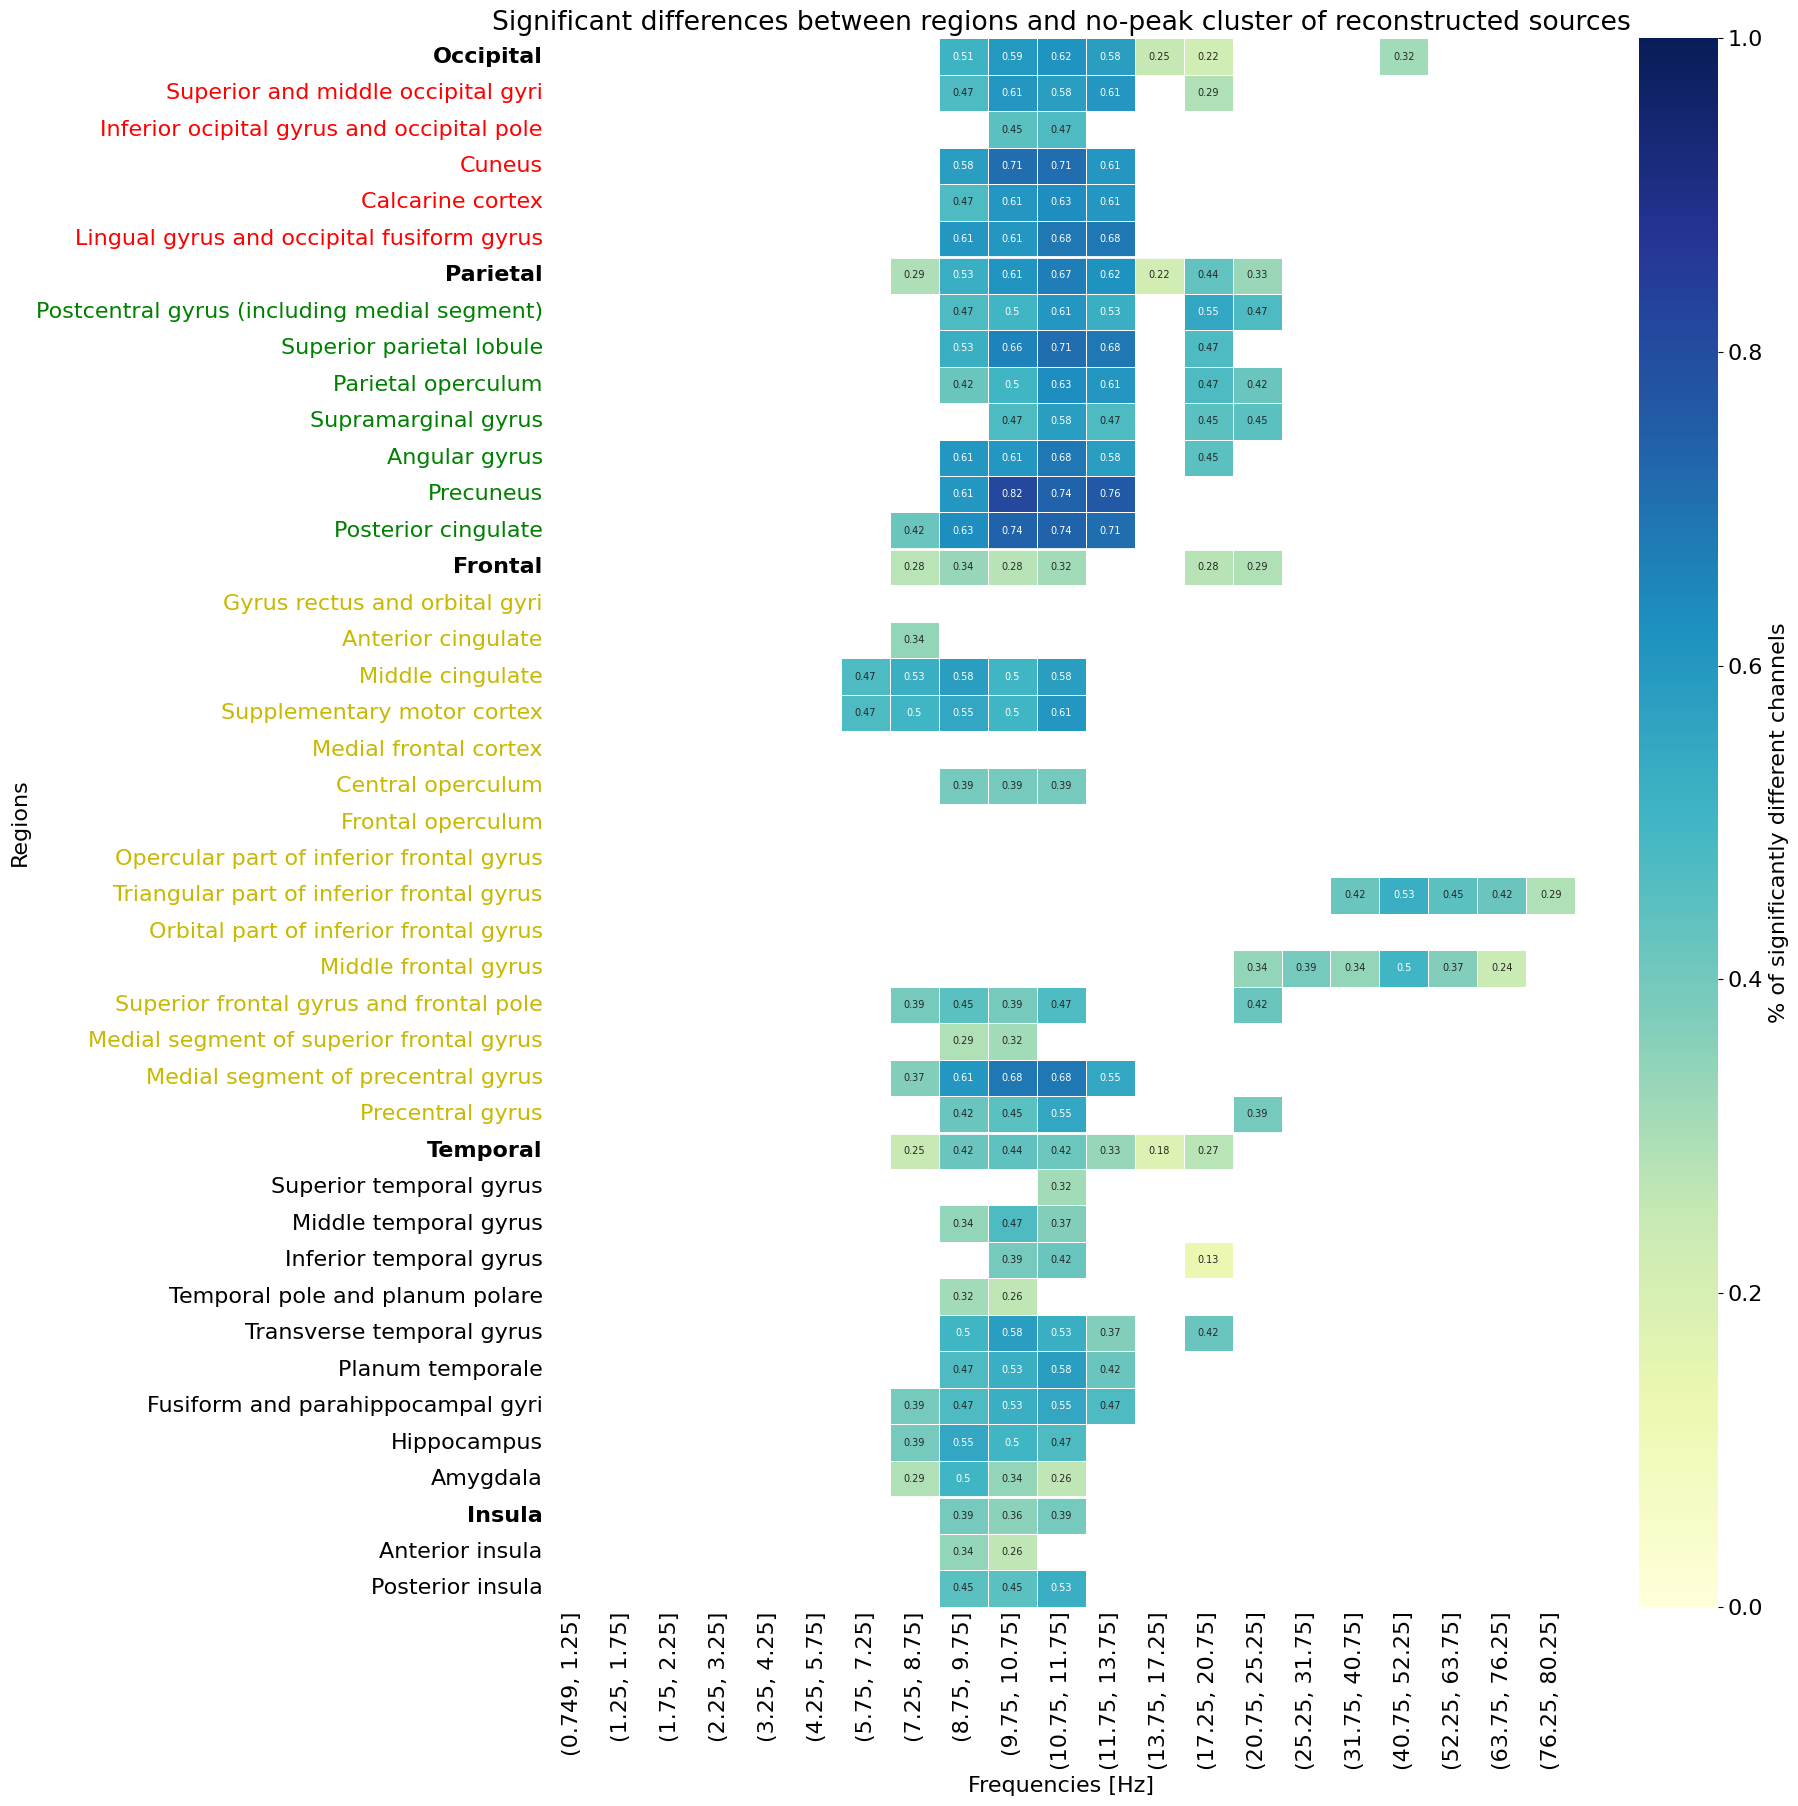

In [21]:
fig, ax = plot_region_difference_heatmap(
    src.regional_diff,
    title=f"Significant differences between regions and no-peak cluster of {src.name}",
    output_path=f"images/{src.name}_all_regional_differences.png",
    annot_fontsize=7,
)

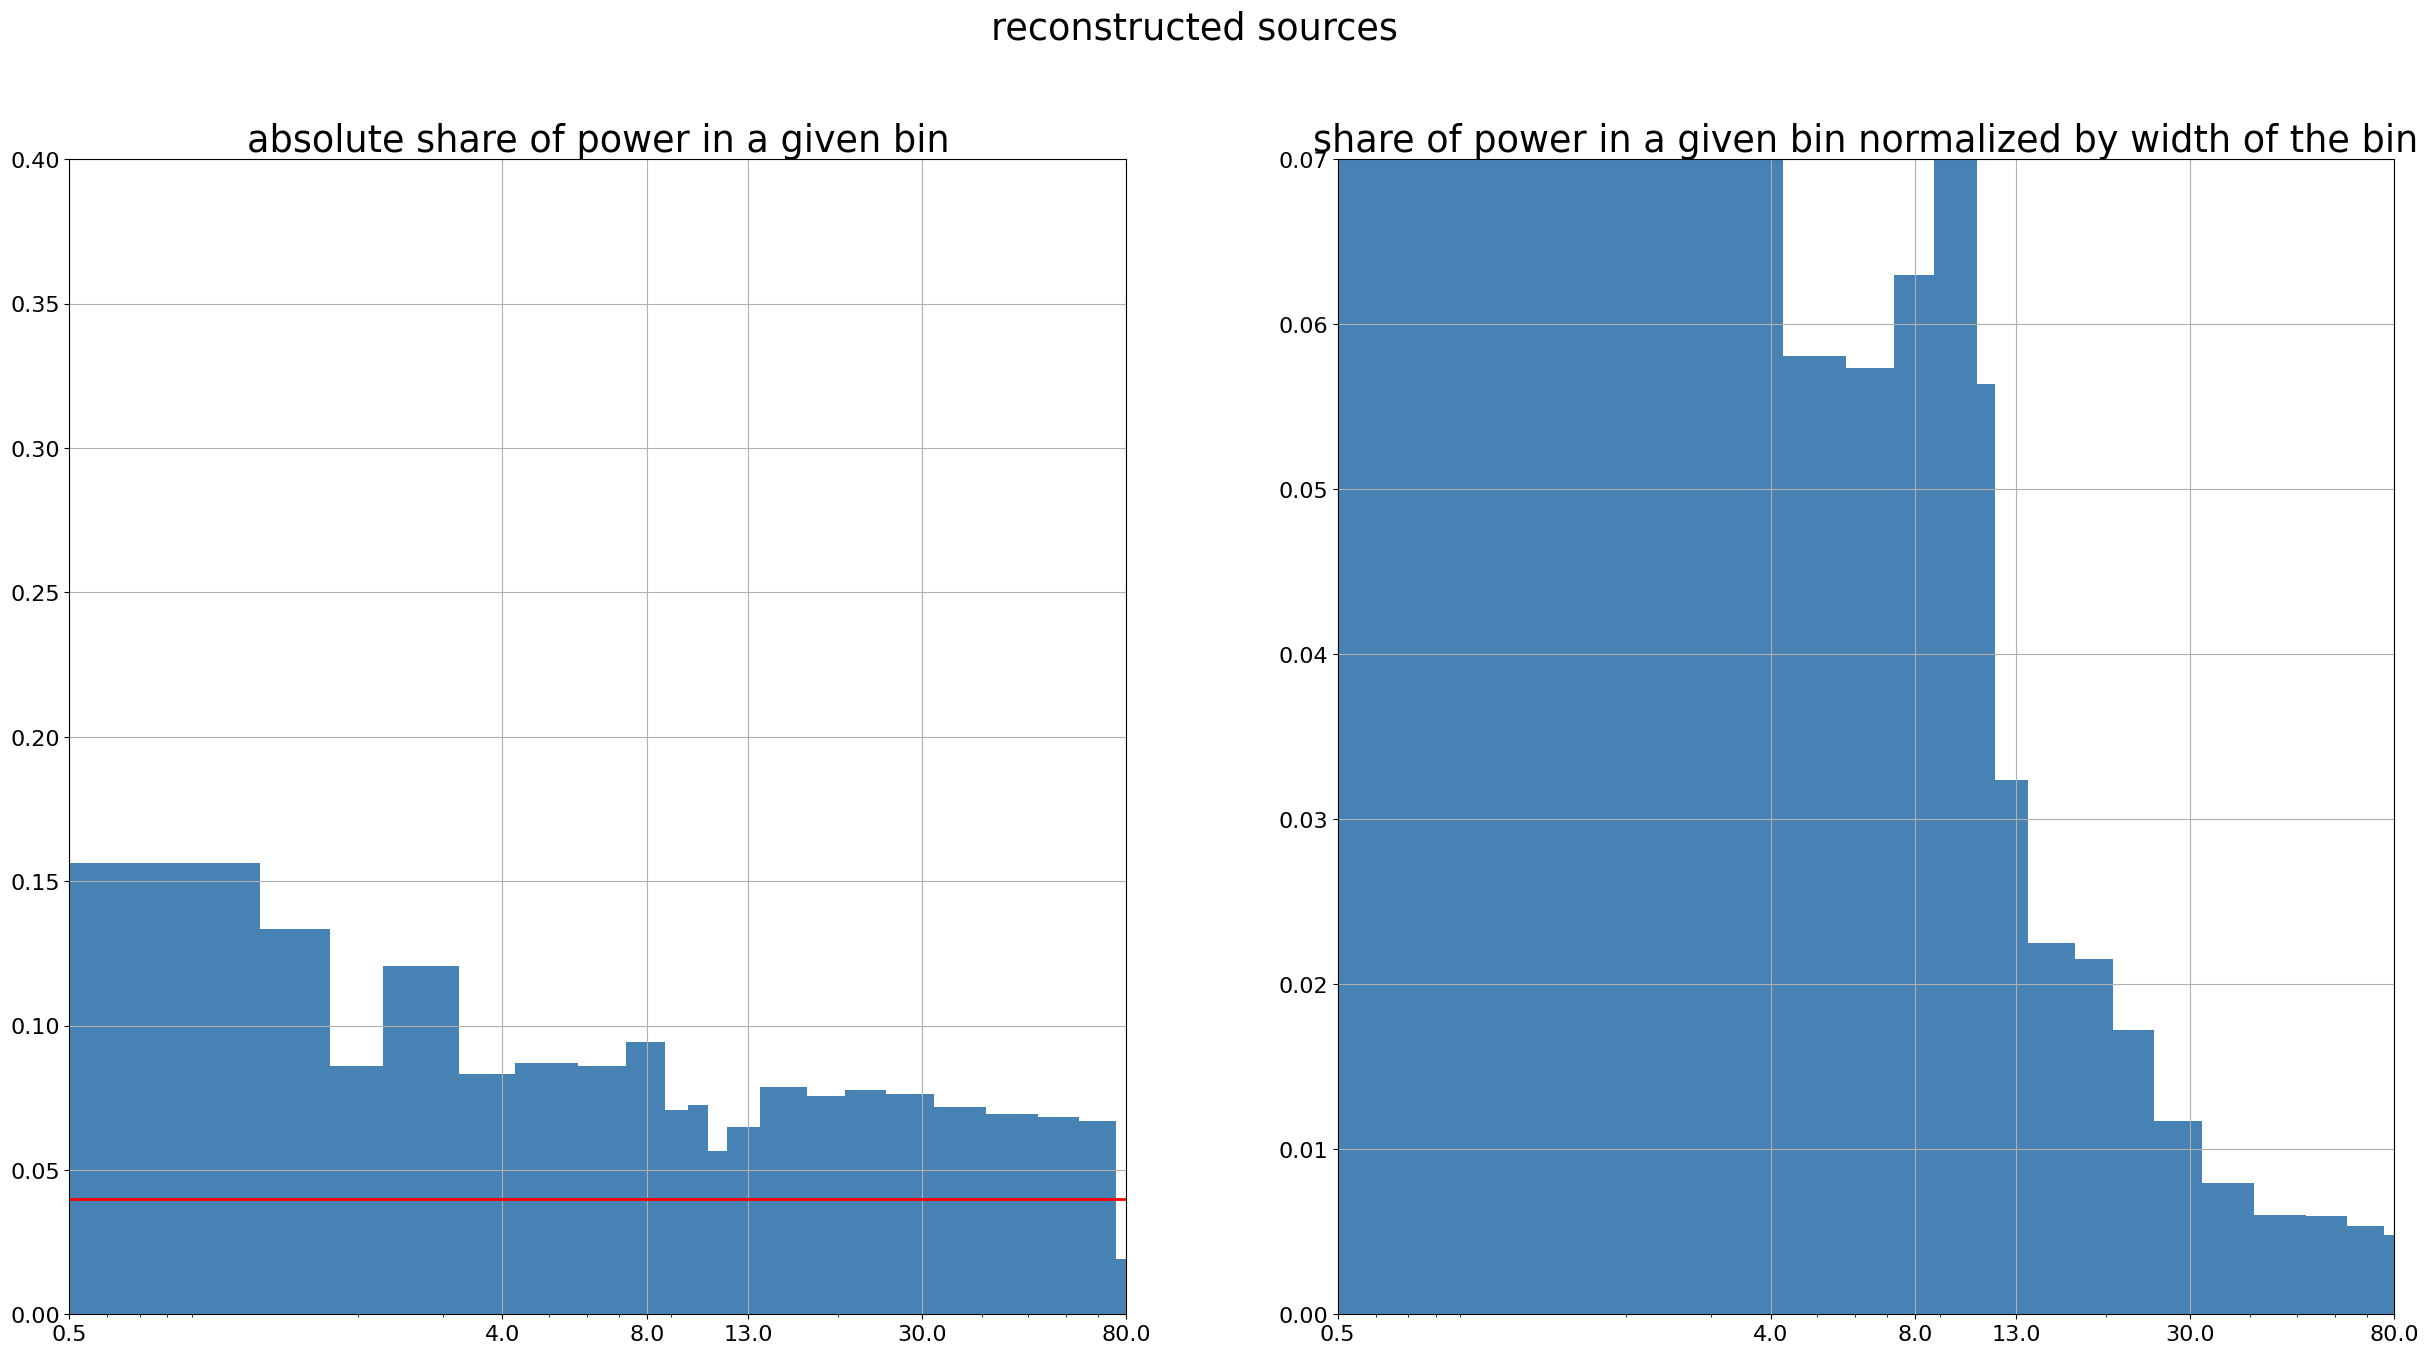

In [22]:
fig, _ = plot_histogram(src.psd, src.colbin, src.name, summary=PLOT_SUMMARY)
fig.savefig(f"images/{src.name}_power_share.png", dpi=600, bbox_inches="tight")

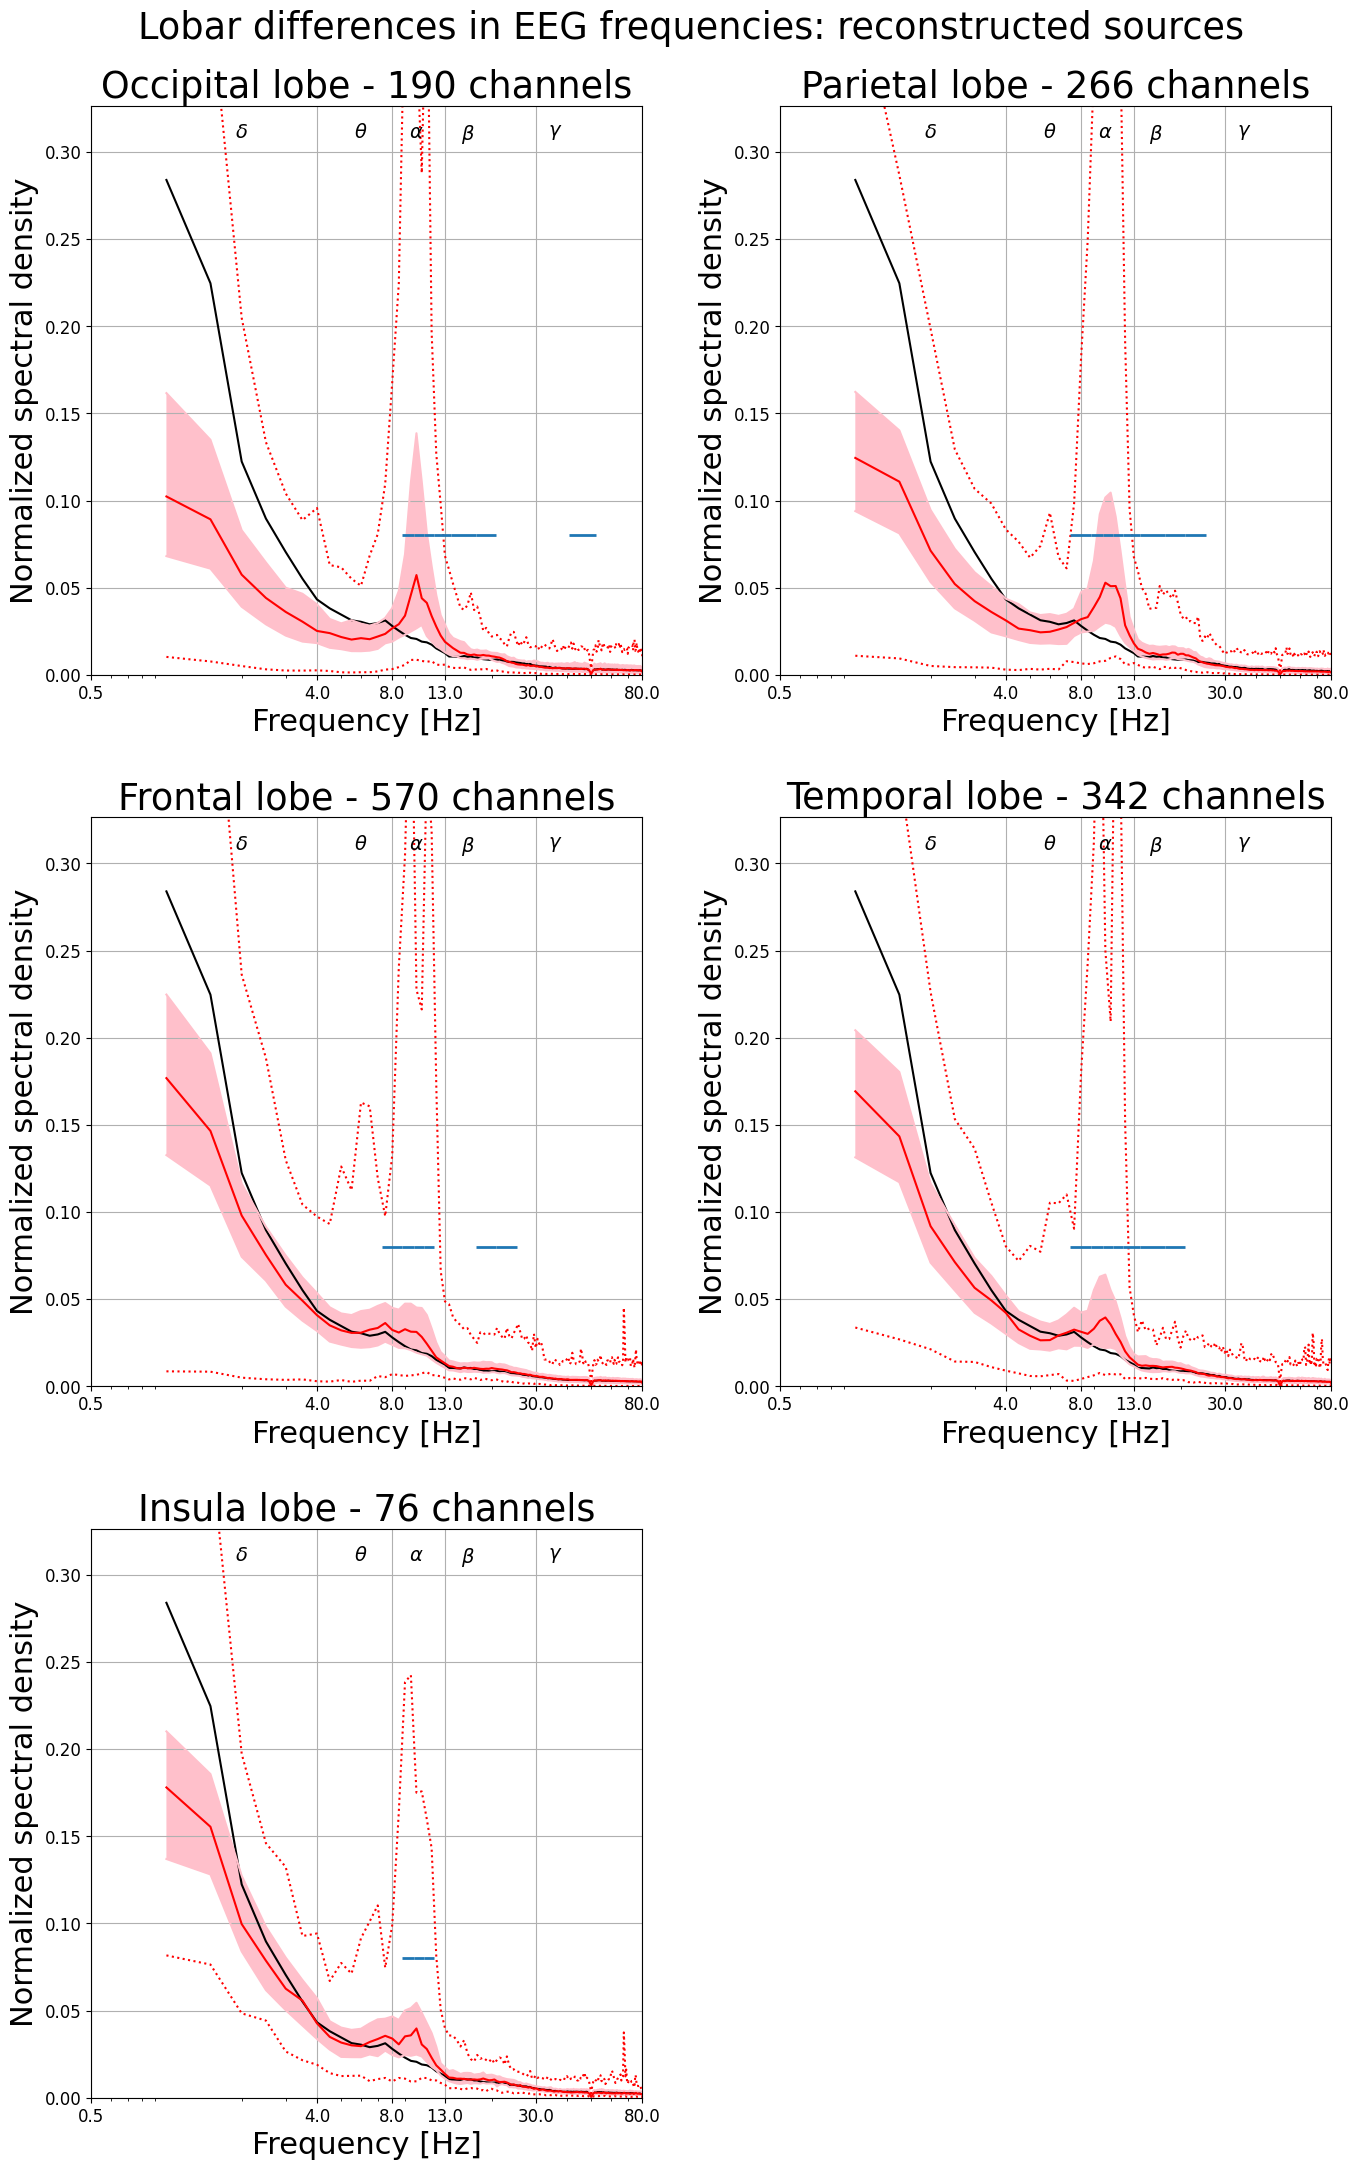

In [23]:
fig, axes = plot_lobes(
    src.psd_clust, src.psd, src.f, src.smal, src.name, src.sig_lobes,
    summary=PLOT_SUMMARY, tick_labelsize=12,
)
fig.savefig(f"images/{src.name}_lobar_differences.pdf", bbox_inches="tight")

## Side-by-side

Both ctx objects coexist; iterate or compare freely.

In [24]:
for ctx in (ieeg, src):
    print(
        f"{ctx.name}: "
        f"{len(ctx.psd)} channels, "
        f"k={ctx.psd_clust['clusters'].nunique()}, "
        f"no-peak={ctx.smal}, "
        f"intervals={len(ctx.colbin.categories) if ctx.colbin is not None else None}"
    )

intracranial data: 1772 channels, k=8, no-peak=[3], intervals=22
reconstructed sources: 1444 channels, k=11, no-peak=[8], intervals=21
